In [1]:
import os
os.listdir("/kaggle/input/asvspoof2019-la/LA")



['ASVspoof2019_LA_dev',
 'ASVspoof2019_LA_train',
 'ASVspoof2019_LA_cm_protocols',
 'ASVspoof2019_LA_eval',
 'ASVspoof2019_LA_asv_protocols',
 'README.LA.txt',
 'ASVspoof2019_LA_asv_scores']

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

# Paths
audio_dir = "/kaggle/input/asvspoof2019-la/LA/ASVspoof2019_LA_train/flac"
protocol_path = "/kaggle/input/asvspoof2019-la/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"
save_dir = "/kaggle/working/mfcc_npy/train"
os.makedirs(save_dir, exist_ok=True)

# Load protocol file
df = pd.read_csv(protocol_path, sep=' ', header=None, names=["speaker", "file", "system", "unused", "label"])
print(f"📃 Total files in protocol: {len(df)}")

# MFCC Extraction function
def extract_mfcc(file_path, n_mfcc=40, max_len=400):
    y, sr = librosa.load(file_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc

# Get already saved files (if any)
done_files = set([f.split(".npy")[0] for f in os.listdir(save_dir)])
print(f"✅ Already saved MFCCs: {len(done_files)}")

errors = []
processed = 0

# Extraction loop
for _, row in tqdm(df.iterrows(), total=len(df)):
    file_id = row["file"]
    label = row["label"]
    npy_name = f"{file_id}_{label}"

    # Skip if already processed
    if npy_name in done_files:
        continue

    flac_path = os.path.join(audio_dir, f"{file_id}.flac")
    save_path = os.path.join(save_dir, f"{npy_name}.npy")

    if os.path.exists(flac_path):
        try:
            mfcc = extract_mfcc(flac_path)
            np.save(save_path, mfcc)
            processed += 1
            if processed % 1000 == 0:
                print(f"📝 Saved {processed} new files so far...")
        except Exception as e:
            errors.append((file_id, str(e)))
    else:
        errors.append((file_id, "File not found"))

# Final summary
print(f"\n🎉 Extraction Complete.")
print(f"🟩 Newly processed and saved: {processed}")
print(f"📂 Total in save_dir: {len(os.listdir(save_dir))}")
if errors:
    print(f"⚠️ Errors on {len(errors)} files. First 5 shown:\n", errors[:5])


📃 Total files in protocol: 25380
✅ Already saved MFCCs: 0


  4%|▍         | 1007/25380 [00:39<09:41, 41.89it/s]

📝 Saved 1000 new files so far...


  8%|▊         | 2006/25380 [01:04<09:18, 41.83it/s]

📝 Saved 2000 new files so far...


...

 59%|█████▉    | 15007/25380 [05:51<03:51, 44.85it/s]

📝 Saved 15000 new files so far...


 63%|██████▎   | 16004/25380 [06:14<03:25, 45.52it/s]

📝 Saved 16000 new files so far...


 66%|██████▌   | 16674/25380 [06:29<02:58, 48.68it/s]

In [10]:
import os

train_dir = "/kaggle/working/mfcc_npy/train"
files = os.listdir(train_dir)
print(f"Total MFCC .npy files: {len(files)}")
print("Sample files:", files[:5])  # Just first 5


Total MFCC .npy files: 25380
Sample files: ['LA_T_4213352_spoof.npy', 'LA_T_6803180_spoof.npy', 'LA_T_7545613_spoof.npy', 'LA_T_8625119_spoof.npy', 'LA_T_2743087_spoof.npy']


In [11]:
import torch
from torch.utils.data import Dataset
import numpy as np
import os

class MFCCDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.files = [f for f in os.listdir(data_dir) if f.endswith('.npy')]
        self.label_map = {'bonafide': 0, 'spoof': 1}

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        label_str = file_name.split('_')[-1].replace('.npy', '')  # 'spoof' or 'bonafide'
        label = self.label_map[label_str]
        mfcc = np.load(os.path.join(self.data_dir, file_name))
        mfcc_tensor = torch.tensor(mfcc, dtype=torch.float32)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return mfcc_tensor, label_tensor


In [12]:
from torchvision import transforms

# For ViT we need shape: [batch, 1, height, width]
class ToImage:
    def __call__(self, tensor):
        return tensor.unsqueeze(0)  # from [40, 400] to [1, 40, 400]


In [13]:
class MFCCDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.files = [f for f in os.listdir(data_dir) if f.endswith('.npy')]
        self.label_map = {'bonafide': 0, 'spoof': 1}
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        label_str = file_name.split('_')[-1].replace('.npy', '')
        label = self.label_map[label_str]
        mfcc = np.load(os.path.join(self.data_dir, file_name))
        mfcc_tensor = torch.tensor(mfcc, dtype=torch.float32)
        if self.transform:
            mfcc_tensor = self.transform(mfcc_tensor)
        return mfcc_tensor, torch.tensor(label, dtype=torch.long)


In [14]:
import timm
import torch.nn as nn

class ViTClassifier(nn.Module):
    def __init__(self):
        super(ViTClassifier, self).__init__()
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True)
        self.vit.head = nn.Linear(self.vit.head.in_features, 2)  # 2 classes: bonafide or spoof

    def forward(self, x):
        # Resize to [B, 3, 224, 224] expected by pretrained ViT
        x = torch.nn.functional.interpolate(x, size=(224, 224))
        x = x.repeat(1, 3, 1, 1)  # from 1-channel to 3-channel
        return self.vit(x)


Epoch 1, Loss: 0.1450
✅ Validation Accuracy: 97.97%
Epoch 2, Loss: 0.0420
✅ Validation Accuracy: 97.66%
Epoch 3, Loss: 0.0230
✅ Validation Accuracy: 98.70%
Epoch 4, Loss: 0.0115
✅ Validation Accuracy: 99.00%
Epoch 5, Loss: 0.0099
✅ Validation Accuracy: 98.90%


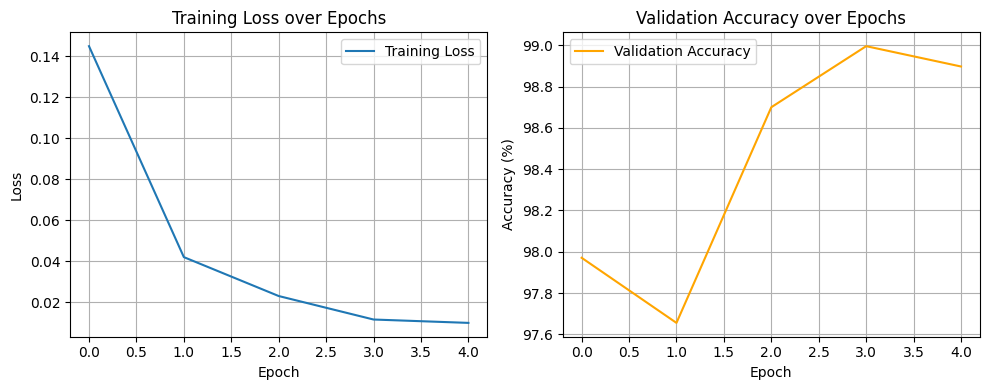

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from torchvision import transforms

# Dataset & Transform
transform = transforms.Compose([ToImage()])
full_dataset = MFCCDataset("/kaggle/working/mfcc_npy/train", transform=transform)

# Split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model, Loss, Optimizer
model = ViTClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5)

# Metrics containers
train_losses = []
val_accuracies = []

# Training Loop
for epoch in range(5):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = 100 * correct / total
    val_accuracies.append(acc)
    print(f"✅ Validation Accuracy: {acc:.2f}%")

# Plotting
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy over Epochs')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
